# CW_08
# Fourier Ptychography

In this workbook you will investigate how iterative phase reconstruction algorithms can be used to perform Fourier Ptychography. To do this, you will create a simplified, Fourier transform based model of a physical 4F imaging setup with an aperture in the Fourier plane and measure the output of illuminating the system from various angles. Then, you will implement an algorithm to combine that information to reverse engineer the phase and amplitude of the object you were illuminating.

In [1]:
# - No modification necessary -

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from ipywidgets import interact, IntSlider

# ----------------------------
# Global simulation parameters
# ----------------------------
wavelength = 532e-9          # meters
k0 = 2 * np.pi / wavelength

N = 1024                      # grid size
dx = 2e-6                    # pixel size (meters)
L = N * dx                   # physical size

# ----------------------------
# Simulation Coordinates
# ----------------------------
x = (np.arange(N) - N//2) * dx
X, Y = np.meshgrid(x, x)

kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx, ky)

fft2 = lambda x: np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x))) / np.sqrt(N*N)
ifft2 = lambda x: np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(x))) * np.sqrt(N*N)

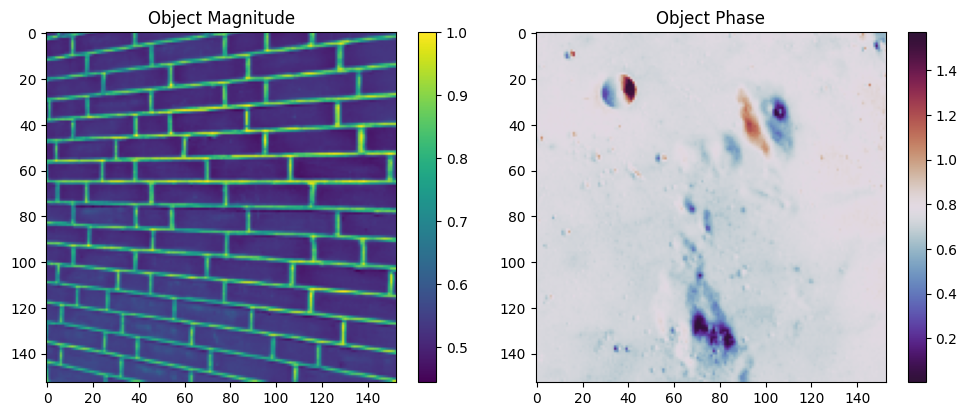

In [2]:
# - No modification necessary -

def generate_object(padding_factor):
    amp_img = transform.resize(data.brick().T, (int(N*(1-padding_factor)), int(N*(1-padding_factor))))
    phase_img = transform.resize(data.moon(), amp_img.shape)

    amp = amp_img / np.max(amp_img)
    phase = phase_img / np.max(phase_img) * 0.5 * np.pi

    obj_small = amp * np.exp(1j * phase)

    start = (N - int(N*(1-padding_factor))) // 2
    end = start + int(N*(1-padding_factor))
    
    obj = np.ones((N, N), dtype=complex)
    obj[start:end, start:end] = obj_small

    return obj, start, end

padding_factor = 0.85         # object padding

obj, start, end = generate_object(padding_factor)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Magnitude
im0 = axes[0].imshow(np.abs(obj[start:end, start:end]))
axes[0].set_title("Object Magnitude")
plt.colorbar(im0, ax=axes[0])

# Phase
im1 = axes[1].imshow(np.angle(obj[start:end, start:end]), cmap='twilight_shifted')
axes[1].set_title("Object Phase")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# Part 1

In the first part of this exercise you will work on implementing the aperture of the optical system. To model the aperture and the effect of tilted illumination, you will create a circular low pass filter that has been shifted from the origin.

Up to this point, we have used the angular spectrum method for all optical propagation. For computational simplicity, however, it is often advantageous to assume that we can directly use the Fourier transform. When making this assumption, we must be careful to properly translate the physical parameters of our system into the simulation space.

To begin our implementation, implement the function create_circular_aperture. This function will take a radius (in meters) of our system's aperture, as well as the focal length of the lenses used in the 4F, and the kx and ky values of our input illumination. This function should return an aperture mask of the size in Fourier space coordinates that corresponds to the physical size of the aperture, and is shifted according to the axis of illumination to reflect what spatial frequencies will be passed by the system for this illumination.

After you have implemented the aperture generation function, use the provided visualization code to check what the superposition of all the frequencies that we are going to sample looks like. 

Then, answer the following questions:
1) Approximately how much faster is it to use a Fourier transform instead of the angular spectrum method to propagate through a 2F system?
2) Approximately how much have we improved the size of our "effective" aperture?

In [3]:
def create_circular_aperture(radius, f, kx, ky):
    rk = k0*radius/f
    Rk = np.sqrt((KX-kx)**2+(KY-ky)**2)
    pupil = np.fft.fftshift((Rk <= rk).astype(float))
    return pupil


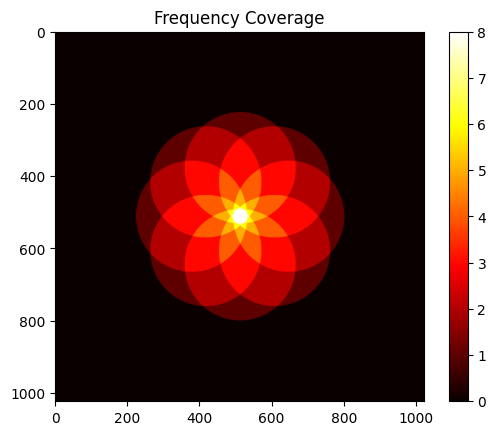

In [4]:
# - No modification necessary -

num_angles = 8              # number of illuminations
angles = np.linspace(0, 2*np.pi, num_angles, endpoint=False)
deflection_angle = 2 / 180 * np.pi
deflection_k = np.sin(deflection_angle) * k0
k_vectors = [(deflection_k*np.sin(a), deflection_k*np.cos(a)) for a in angles]

f = 50e-3                
aperture_radius = 20e-4       # meters (Fourier plane physical radius)

def plot_frequency_coverage(k_vectors):
    coverage = np.zeros_like(KX)

    for (kx, ky) in k_vectors:
        mask = create_circular_aperture(aperture_radius, f, kx, ky)
        coverage += mask

    plt.imshow(coverage, cmap='hot')
    plt.title("Frequency Coverage")
    plt.colorbar()
    plt.show()

plot_frequency_coverage(k_vectors)

## Discussion
1) It is approximately 4 times faster to just use a Fourier transform directly, since a 2F requires 4 Fourier transforms if done with ASM.
2) Based on the deflection and aperture sized used, we seem to have about doubled the radius of our aperture.

# Part 2

Now that we have modeled our aperture, we can connect the whole system together to simulate its output under different illumination sources.

Here you should complete the simulate_measurements function. This function will iterate through the list of provided k vectors (representing the different directions of illumination) and propagate our sample (under gaussian illumination) through the system with the appropriate aperture. 

After you have implemented this, you can use the provided script to check the different outputs of the system.

Then, answer the following question:
1) What do you observe about the differences between different illumination angles? How can you explain what content you see based on what aperture was used?

In [5]:
def generate_gaussian_beam(waist):
    R2 = X**2 + Y**2
    amplitude = np.exp(-R2 / waist**2)
    return amplitude

def simulate_measurements(obj, k_vectors, aperture_radius, waist, f):
    measurements = []

    for (kx, ky) in k_vectors:
        field = obj * generate_gaussian_beam(waist)
        field = fft2(field)
        field *= create_circular_aperture(aperture_radius, f, kx, ky)
        field = ifft2(field)
        
        intensity = np.abs(field)**2
        measurements.append(intensity)

    return np.array(measurements)

In [6]:
# - No modification necessary -

waist = 300e-6
measurements = simulate_measurements(
    obj, k_vectors, aperture_radius, waist, f
)

def show_measurement(num):
    plt.imshow(measurements[num][start:end, start:end], cmap='gray')
    plt.title(f"Measurement {num}")
    plt.colorbar()
    plt.show()

interact(
    show_measurement,
    num=IntSlider(min=0, max=num_angles-1, step=1)
)

interactive(children=(IntSlider(value=0, description='num', max=7), Output()), _dom_classes=('widget-interact'…

<function __main__.show_measurement(num)>

## Discussion
Under different angles of illumination we expect that the spatial frequencies passed by our imaging system will change. Because our aperture is translated in Fourier space but remains a constant size, we expect that based on the direction of illumination we should only see spatial frequencies passed near the same spatial frequency of the angle of illumination (i.e. if our light is pointing to the right, we expect to predominantly see lateral spatial frequencies, or vertical lines, and if our light is pointing up we expect to mainly see vertical spatial frequencies, or horizontal lines). This is what we observe in our measured outputs.

# Part 3

Now that we have obtained the output measurements of our system, it is time to combine this information back into the phase and amplitude of our initial object. To do this, you will implement a version of the Ptychographic Iterative Engine (PIE) shown in the paper "Electron fourier ptychography for phase reconstruction" [Zhao, J. et al., Sci Rep 15, 37955 (2025). https://doi.org/10.1038/s41598-025-21638-7 ]. A detailed explanation of the algorithm may be found in the paper's supplementary.

For simplicity, the outline of the algorithm has been provided for you. You will be responsible for filling in each step to complete the implementation.

After you have finished implementing the algorithm, use the provided code to run it and visualize the results.

Then, answer the following question:
1) Can you explain in your own words what this algorithm is doing? What have we seen in class that this resembles? 

In [7]:
def pie_reconstruction(measurements, waist, f, k_vectors, aperture_radius, num_iterations, alpha):
    input_beam = generate_gaussian_beam(waist)
    F_exit = fft2(input_beam)
    
    wave_tfs = [create_circular_aperture(aperture_radius, f, kx, ky) for (kx, ky) in k_vectors]

    for it in range(num_iterations):
        for j, I in enumerate(measurements):  
            # ---------------------------------------------------
            # Step 1: generate the jth exit wave in Fourier space
            # ---------------------------------------------------
            F_im = F_exit * wave_tfs[j]

            # -------------------------------------------------------------------
            # Step 2: Move the exit wave to the image plane and set the amplitude
            # -------------------------------------------------------------------
            img_wave = ifft2(F_im)
            updated = np.sqrt(I) * np.exp(1j * np.angle(img_wave))

            # --------------------------------------------------------
            # Step 3: Return to Fourier space and calculate difference
            # --------------------------------------------------------
            F_updated = fft2(updated)
            diff = F_updated - F_exit

            # -------------------------------------------------------------
            # Step 4: Perform update routine on the Fourier space exit wave
            # -------------------------------------------------------------
            correction = alpha * np.conj(wave_tfs[j])/(np.max(np.abs(wave_tfs[j]))**2)*diff
            F_exit += correction

        alpha *= 0.933  # decay

    exit_wave = ifft2(F_exit)
    obj = exit_wave/input_beam

    return obj

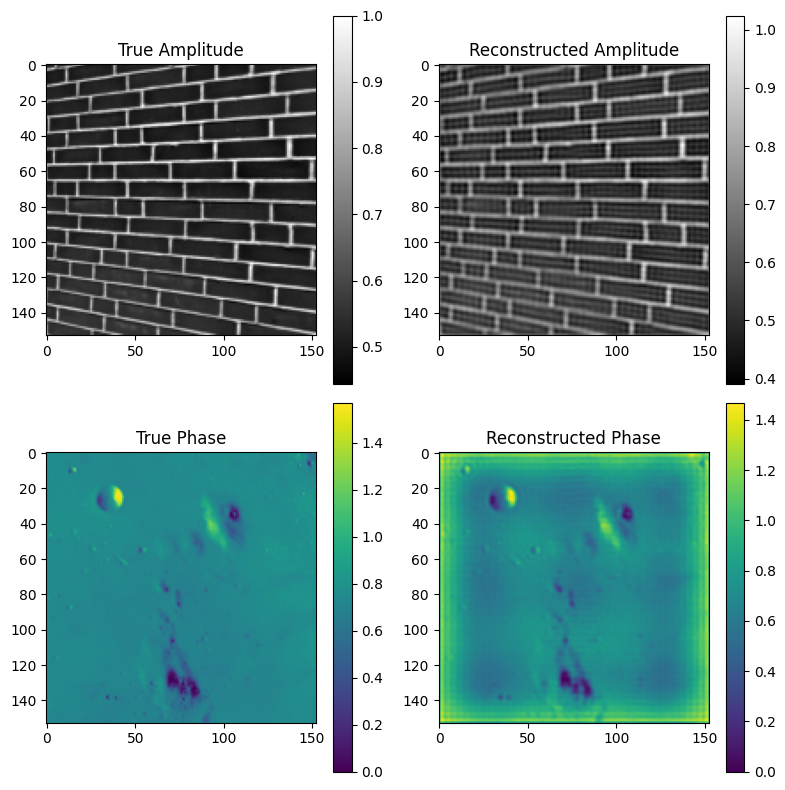

In [9]:
# - No modification necessary -

def plot_results(obj, recon):
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))

    im1 = axs[0,0].imshow(np.abs(obj[start:end, start:end]), cmap='gray')
    axs[0,0].set_title("True Amplitude")
    plt.colorbar(im1, ax=axs[0, 0])

    im2 = axs[1,0].imshow(np.angle(obj[start:end, start:end]) - np.min(np.angle(obj[start:end, start:end])), cmap='viridis')
    axs[1,0].set_title("True Phase")
    plt.colorbar(im2, ax=axs[1,0])

    im3 = axs[0,1].imshow(np.abs(recon[start:end, start:end]), cmap='gray')
    axs[0,1].set_title("Reconstructed Amplitude")
    plt.colorbar(im3, ax=axs[0, 1])

    im4 = axs[1,1].imshow(np.angle(recon[start:end, start:end]) - np.min(np.angle(recon[start:end, start:end])), cmap='viridis')
    axs[1,1].set_title("Reconstructed Phase")
    plt.colorbar(im4, ax=axs[1, 1])

    plt.tight_layout()
    plt.show()

alpha = 1                  # PIE step size
num_iterations = 50

recon = pie_reconstruction(
    measurements, waist, f, k_vectors, aperture_radius, num_iterations, alpha
)

# Results
plot_results(obj, recon)

## Discussion
1) The algorithm begins by moving the probe beam to the Fourier plane of the 4F. Then, we go from Fourier space to the image plane. At the image plane, we clamp the amplitude to the known output amplitude. Then we propagate back to the Fourier plane. At the Fourier plane we do not do a similar update, since we do not have a measurement to use. Instead, we calculate a difference between the field before and after the propagation to and back from the image plane and then cancel out the effect of the specific aperture in use. The resulting quantity becomes the actual update we apply to our guess of the field. This means that we keep one shared guess of the field across the different apertures (which represent the different illumination sources). We repeat this process for each aperture, and call this one iteration. Then, the scaling parameter for each update is reduced, and a new iteration begins. This behavior is reminiscent of the Fienup algorithm, but with modifications to support multiple illumination sources.